In [4]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/meat-freshness-image-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'meat-freshness-image-dataset' dataset.
Path to dataset files: /kaggle/input/meat-freshness-image-dataset
Contents of base_path (/kaggle/input):
['meat-freshness-image-dataset']
Contents of path (/kaggle/input/meat-freshness-image-dataset):
['Meat Freshness.v1-new-dataset.multiclass']


In [5]:
import os

# Update path based on cell 1 results
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')

# List class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Data classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Data classes found: ['valid', 'train']



--- Displaying sample images from dataset (/kaggle/input/meat-freshness-image-dataset/Meat Freshness.v1-new-dataset.multiclass) ---
Found 2266 images. Displaying 6 sample images:


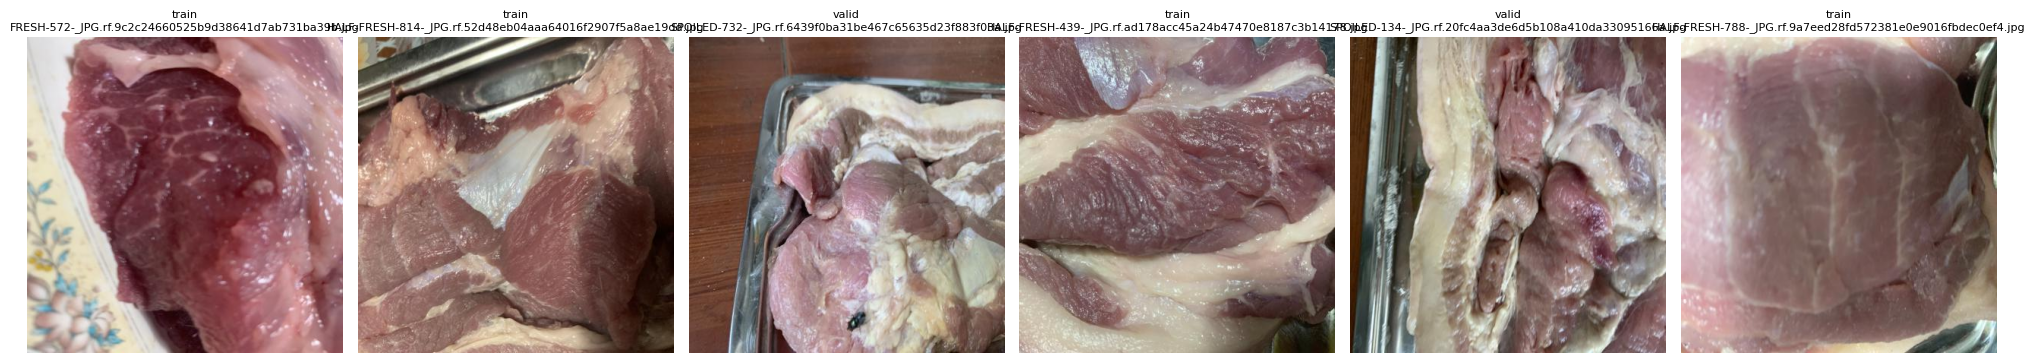

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use updated path
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')
print(f"\n--- Displaying sample images from dataset ({data_path}) ---")
display_sample_images(data_path)

In [7]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
    print(f'Found GPU at: {device_name}')

# List physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [19]:
import os
import pandas as pd
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Function to create a dataframe with paths and labels from filenames
def create_df(directory):
    files = [f for f in os.listdir(directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    labels = []
    for f in files:
        if 'HALF-FRESH' in f.upper():
            labels.append('HALF-FRESH')
        elif 'SPOILED' in f.upper():
            labels.append('SPOILED')
        elif 'FRESH' in f.upper():
            labels.append('FRESH')
        else:
            labels.append('UNKNOWN')
    return pd.DataFrame({'filename': [os.path.join(directory, f) for f in files], 'label': labels})

# Prepare dataframes
train_df = create_df(train_dir)
valid_df = create_df(valid_dir)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")
print(f"Classes: {train_df['label'].unique()}")

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='label',
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_dataframe(
    valid_df,
    x_col='filename',
    y_col='label',
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical'
)

num_classes = len(train_df['label'].unique())

# Build InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    verbose=1
)

Training samples: 1815
Validation samples: 451
Classes: ['SPOILED' 'FRESH' 'HALF-FRESH']
Found 1815 validated image filenames belonging to 3 classes.
Found 451 validated image filenames belonging to 3 classes.
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5614 - loss: 1.0172 - val_accuracy: 0.7583 - val_loss: 0.5655
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 785ms/step - accuracy: 0.7598 - loss: 0.5520 - val_accuracy: 0.8271 - val_loss: 0.4385
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 808ms/step - accuracy: 0.7758 - loss: 0.4917 - val_accuracy: 0.8381 - val_loss: 0.3752
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 786ms/step - accuracy: 0.8204 - loss: 0.4191 - val_accuracy: 0.8448 - val_loss: 0.3539
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 810ms/step - accuracy: 0.8281 - loss: 0.3917 - val_accuracy: 0.8736 - val_loss: 0.3175
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 81s 785ms/step - accuracy: 0.8397 - loss: 0.3651 - val_accuracy: 0.8914 - val_loss: 0.2745
Epoch 7/10
57/57 ━━

Final Training Accuracy: 0.8678
Final Validation Accuracy: 0.8980


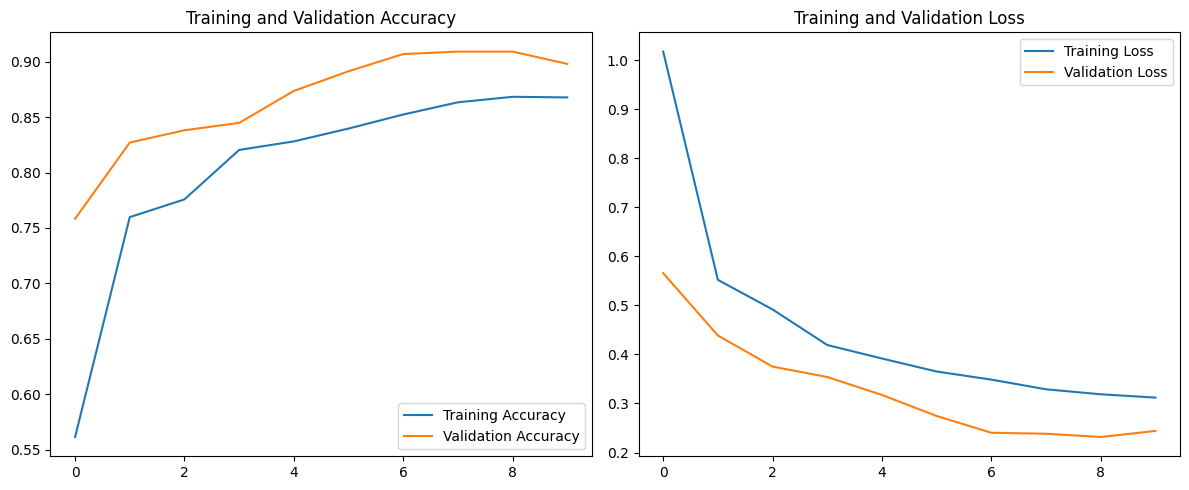

In [20]:
import matplotlib.pyplot as plt

# Summarize results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()